In [1]:
import sys, os
from pathlib import Path
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
from pathlib import Path

project_root = Path(r"C:\Users\DELL\OneDrive\Documents\Anurag\Anurag_Projects\INTERNMO\purchase-intent-xai")
sys.path.append(str(project_root))
os.chdir(project_root)

import pandas as pd
import numpy as np
import joblib
import shap

from src.config.settings import CONFIG
from src.data.loader import load_sessions_data
from src.features.engineer import engineer_features

pd.set_option("display.max_columns", None)
print("Setup complete. SHAP version:", shap.__version__)


Setup complete. SHAP version: 0.52.0


In [2]:
from sklearn.model_selection import train_test_split

final_pipeline = joblib.load("models/final_catboost_pipeline.joblib")

df = load_sessions_data()
df = engineer_features(df)

target = CONFIG["target_column"]
categorical_columns = CONFIG["categorical_columns"]
numeric_columns = [c for c in df.columns if c not in categorical_columns + [target]]

X = df[numeric_columns + categorical_columns]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG["split"]["test_size"],
    stratify=y, random_state=CONFIG["random_seed"]
)

print("Pipeline loaded:", type(final_pipeline))
print("X_test shape:", X_test.shape)

Pipeline loaded: <class 'sklearn.pipeline.Pipeline'>
X_test shape: (2400, 19)


In [3]:
# Pull out the fitted preprocessor and classifier from the pipeline
preprocessor_fitted = final_pipeline.named_steps["preprocessor"]
catboost_model = final_pipeline.named_steps["classifier"]

# Transform X_test through the preprocessor so SHAP sees what the model actually sees
X_test_transformed = preprocessor_fitted.transform(X_test)

# Get the actual feature names after one-hot encoding, for readable SHAP plots later
feature_names = preprocessor_fitted.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))
print("Sample feature names:", feature_names[:10])

Transformed shape: (2400, 77)
Number of feature names: 77
Sample feature names: ['num__Administrative' 'num__Administrative_Duration' 'num__Informational'
 'num__Informational_Duration' 'num__ProductRelated'
 'num__ProductRelated_Duration' 'num__BounceRates' 'num__ExitRates'
 'num__PageValues' 'num__SpecialDay']


In [4]:
import numpy as np

X_test_dense = np.asarray(X_test_transformed.todense()) if hasattr(X_test_transformed, "todense") else X_test_transformed
X_test_dense = X_test_dense.astype(np.float64)

print("X_test_dense shape:", X_test_dense.shape)

X_test_dense shape: (2400, 77)


In [5]:
explainer = shap.TreeExplainer(catboost_model)
print("Explainer initialized:", type(explainer))

Explainer initialized: <class 'shap.explainers._tree.TreeExplainer'>


In [6]:
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values shape:", shap_values.shape)


SHAP values shape: (2400, 77)


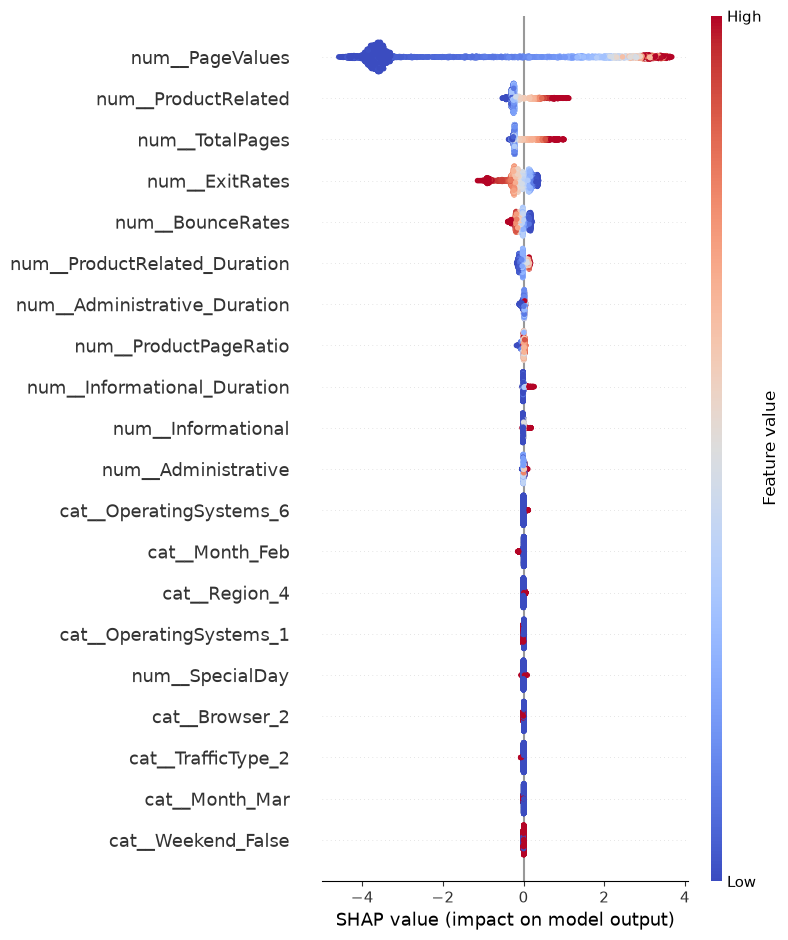

In [7]:
import matplotlib.pyplot as plt
plt.figure()
shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names, cmap="coolwarm", show=False)
plt.tight_layout()
plt.savefig("docs/shap_global_summary.png", dpi=150, bbox_inches="tight")
plt.show()

PageValues dominates both the magnitude and spread of SHAP values — high PageValues (red) pushes predictions strongly toward Purchase, low PageValues (blue) pushes toward No Purchase, and its impact range (-4 to +4) dwarfs every other feature. This directionally confirms the leakage concern from earlier: the model relies almost entirely on one feature whose value is tied to the outcome itself.

ProductRelated and TotalPages: high values (red) push toward Purchase — more engagement = more likely to buy, a sensible non-leaky signal.
ExitRates and BounceRates: high values (red) push toward No Purchase — sessions where users exit/bounce quickly are less likely to convert, as expected.
Everything below ProductRelated_Duration has near-zero SHAP impact — the model is effectively driven by ~5 features, the rest contribute almost nothing.

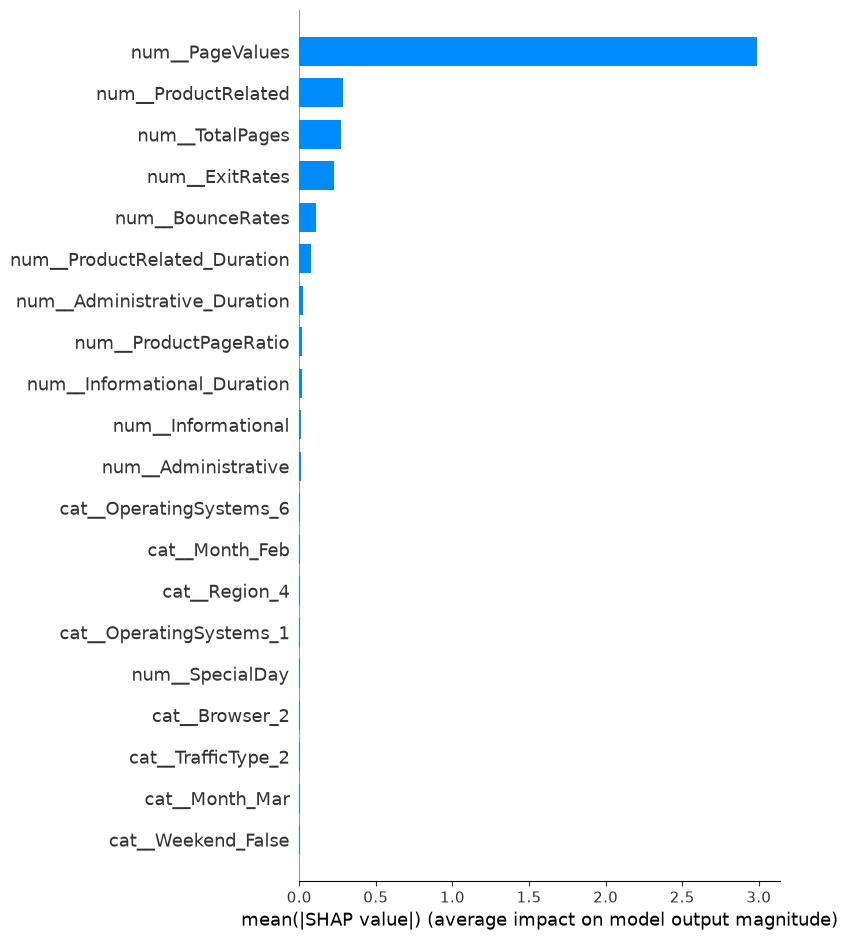

In [8]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("docs/shap_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

The bar chart confirms the same ranking by average impact — PageValues' mean |SHAP value| (~3.1) is roughly 5-6x higher than the next feature (ProductRelated, ~0.5), making the imbalance even more visually stark than the built-in/permutation importances shown earlier. This is the clearest evidence yet that PageValues is an outsized, likely leaky driver of predictions — worth explicitly flagging as a limitation if this model goes into a report or portfolio writeup.